In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# populate a list with years in consideration
years = [ year for year in range(1995, 2024) ]

In [ ]:
# laod file with consumption, gdp values
df_consumption_ngdp = pd.read_csv("data/81000-0019_en_flat.csv")
columns_to_keep = ['time', 'value_variable_code', 'value']
# filter the dataFrame with required columns only
df_consumption_ngdp = df_consumption_ngdp[columns_to_keep]
# set time as the index of the DataFrame
df_consumption_ngdp = df_consumption_ngdp.set_index('time')
# sort the values by time in ascending order
df_consumption_ngdp =  df_consumption_ngdp.sort_index()
df_consumption_ngdp.head()

,value_variable_code,value
time,,
1991,VGR034,22.051
1991,VGR022,-8.012
1991,VGR038,1599.622
1991,VGR042,44.948
1991,VGR094,1048.813


In [ ]:
# Final consumption expenditure code: VGR039
# Here we generate the consumption dataset
df_consumption = df_consumption_ngdp[df_consumption_ngdp['value_variable_code'] == 'VGR039']
df_consumption.head()


,value_variable_code,value
time,,
1991,VGR039,1182.223
1992,VGR039,1280.152
1993,VGR039,1332.731
1994,VGR039,1384.636
1995,VGR039,1428.102


In [ ]:
# Here we get the nominal GDP
df_ngdp = df_consumption_ngdp[df_consumption_ngdp['value_variable_code'] == 'VGR014']
df_ngdp.head()

,value_variable_code,value
time,,
1991,VGR014,1591.61
1992,VGR014,1709.89
1993,VGR014,1757.34
1994,VGR014,1838.02
1995,VGR014,1899.93


In [ ]:
# extract consumption values
consumption_np = np.array(df_consumption.iloc[4:33]['value'])
print("Consumption: ", consumption_np)

ngdp_np = np.array(df_ngdp.iloc[4:33]['value'])
print("NGDP: ", ngdp_np)

savings_np = ngdp_np - consumption_np
print("Savings: ", savings_np)

Consumption:  [1428.102 1463.369 1486.647 1512.169 1572.494 1615.78  1661.443 1685.305
 1720.992 1743.047 1774.779 1817.751 1851.318 1898.685 1925.935 1970.951
 2029.383 2085.128 2133.724 2188.259 2256.248 2333.227 2411.77  2489.022
 2582.621 2517.814 2658.9   2962.239 3123.713]
NGDP:  [1899.93 1928.56 1967.18 2022.31 2077.24 2129.66 2195.53 2223.36 2240.81
 2293.04 2325.71 2426.18 2542.22 2589.28 2493.97 2615.26 2746.91 2799.28
 2866.48 2984.47 3087.03 3195.21 3333.11 3434.03 3537.28 3450.72 3682.34
 3989.39 4219.31]
Savings:  [ 471.828  465.191  480.533  510.141  504.746  513.88   534.087  538.055
  519.818  549.993  550.931  608.429  690.902  690.595  568.035  644.309
  717.527  714.152  732.756  796.211  830.782  861.983  921.34   945.008
  954.659  932.906 1023.44  1027.151 1095.597]


Now, we calculate the Savings Rate as the ratio of Nominal Savings to Nominal GDP for a year t. Here, we assume that Savings is NGDP - Consumption for any year.

In [ ]:
savings_rate_np = savings_np/ngdp_np
savings_rate_np

array([0.24833968, 0.24121158, 0.24427505, 0.25225658, 0.24298877,
       0.24129673, 0.24326108, 0.24200085, 0.23197772, 0.23985321,
       0.23688723, 0.25077653, 0.27177113, 0.26671314, 0.22776337,
       0.24636518, 0.26121242, 0.25511989, 0.2556292 , 0.26678472,
       0.26912016, 0.2697735 , 0.27642052, 0.27518921, 0.26988505,
       0.27035112, 0.27793197, 0.25747069, 0.2596626 ])

Now, we move forward to calculate the depreciation rate of capital stocks. For this, we compute the ratio of capital stock consumption to the gross stock of fixed assets for a year t.

In [ ]:
# load capital stock consumption dataset
df_cstock_cons = pd.read_csv("data/81000-0116_en_flat.csv")
df_cstock_cons = df_cstock_cons.set_index('time')
df_cstock_cons = df_cstock_cons.sort_index()
df_cstock_cons.head()

,statistics_code,statistics_label,time_code,time_label,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,...,3_variable_attribute_label,4_variable_code,4_variable_label,4_variable_attribute_code,4_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label,value_q
time,,,,,,,,,,,,,,,,,,,,,
1995,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,At current prices (bn EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,310.882,unit app.,ABS002,Consumption of fixed capital,e
1996,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,At current prices (bn EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,318.608,unit app.,ABS002,Consumption of fixed capital,e
1997,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,At current prices (bn EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,326.730,unit app.,ABS002,Consumption of fixed capital,e
1998,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,At current prices (bn EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,334.655,unit app.,ABS002,Consumption of fixed capital,e
1999,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,At current prices (bn EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,343.488,unit app.,ABS002,Consumption of fixed capital,e


In [ ]:
# load capital depreciation values in numpy array
capital_depreciation_np = np.array(df_cstock_cons.iloc[:]['value'])
capital_depreciation_np

array([310.882, 318.608, 326.73 , 334.655, 343.488, 358.21 , 369.707,
       377.251, 380.833, 388.085, 395.096, 405.586, 426.258, 444.037,
       454.781, 464.644, 480.775, 498.036, 512.916, 528.535, 545.183,
       561.626, 584.97 , 614.612, 644.318, 666.479, 708.866, 797.686,
       857.85 ])

In [ ]:
# load capital stock values
df_capital_stock = pd.read_csv("data/81000-0130_en_flat.csv")
df_capital_stock = df_capital_stock.set_index("time")
df_capital_stock = df_capital_stock.sort_index()
df_capital_stock.head()

,statistics_code,statistics_label,time_code,time_label,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,...,3_variable_attribute_label,4_variable_code,4_variable_label,4_variable_attribute_code,4_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label,value_q
time,,,,,,,,,,,,,,,,,,,,,
1995,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,Current replacement cost (billion EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,9926.683,unit app.,VGR069,Gross stock of fixed assets,e
1996,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,Current replacement cost (billion EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,10141.463,unit app.,VGR069,Gross stock of fixed assets,e
1997,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,Current replacement cost (billion EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,10379.975,unit app.,VGR069,Gross stock of fixed assets,e
1998,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,Current replacement cost (billion EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,10617.623,unit app.,VGR069,Gross stock of fixed assets,e
1999,81000,National accounts of the Federation,JAHR,Year,DINSG,Germany,DG,Germany,VGRAN1,Types of fixed assets,...,Current replacement cost (billion EUR),WZ08G3,WZ2008: Industries in national accounts,WZ08-A-02,All economic sectors,10833.457,unit app.,VGR069,Gross stock of fixed assets,e


In [ ]:
# load capital stock values in numpy
capital_stock_np = np.array(df_capital_stock.iloc[:]['value'])
print("Capital Stock: ", capital_stock_np)

Capital Stock:  [ 9926.683 10141.463 10379.975 10617.623 10833.457 11162.8   11409.059
 11571.853 11737.691 12028.582 12286.743 12686.318 13492.678 14093.733
 14404.46  14773.587 15335.833 15903.202 16440.01  16975.582 17470.543
 17979.168 18750.671 19769.23  20740.215 21358.268 23092.597 26582.224
 28752.058]


In [ ]:
# we compute the depreciation rate for capital
depreciation_rate_np = capital_depreciation_np/capital_stock_np
print("Depreciation Rate: ", depreciation_rate_np)

Depreciation Rate:  [0.03131781 0.03141637 0.03147695 0.03151882 0.03170622 0.03208962
 0.03240469 0.03260074 0.03244531 0.03226357 0.03215628 0.03197035
 0.0315918  0.03150599 0.03157224 0.03145099 0.03134978 0.03131671
 0.03119925 0.03113501 0.03120584 0.0312376  0.03119728 0.03108932
 0.03106612 0.03120473 0.03069668 0.03000825 0.02983613]


We now calculate the population growth rate for Germany

In [ ]:
# load population data in numpy
df_population = pd.read_csv("data/12411-0001_population.csv", index_col=1)
# df_population = df_population["value"]

# Convert index to datetime so it sorts chronologically
df_population.index = pd.to_datetime(df_population.index, dayfirst=True)

# # Sort by the date
df_population = df_population.sort_index()
df_population = df_population.reset_index()
df_population["year"] = [ year for year in range(1950, 2025) ]
df_population = df_population[["year", "value"]]
df_population = df_population.set_index("year")

popn_np = np.array( df_population.iloc[44:74]['value'] )
popn_np

array([81538603, 81817499, 82012162, 82057379, 82037011, 82163475,
       82259540, 82440309, 82536680, 82531671, 82500849, 82437995,
       82314906, 82217837, 82002356, 81802257, 81751602, 80327900,
       80523746, 80767463, 81197537, 82175684, 82521653, 82792351,
       83019213, 83166711, 83155031, 83237124, 83118501, 83456045])

In [ ]:
# growth in real gdp
population_growth_rate = (np.diff(popn_np) / popn_np[:-1])
population_growth_rate

array([ 3.42041671e-03,  2.37923430e-03,  5.51345055e-04, -2.48216556e-04,
        1.54154812e-03,  1.16919349e-03,  2.19754450e-03,  1.16897912e-03,
       -6.06881692e-05, -3.73456633e-04, -7.61858826e-04, -1.49311006e-03,
       -1.17923964e-03, -2.62085464e-03, -2.44016160e-03, -6.19237193e-04,
       -1.74149737e-02,  2.43808191e-03,  3.02664757e-03,  5.32484226e-03,
        1.20465107e-02,  4.21011403e-03,  3.28032692e-03,  2.74013236e-03,
        1.77667307e-03, -1.40440807e-04,  9.87228301e-04, -1.42512132e-03,
        4.06099720e-03])

In [ ]:
df_capital_share = pd.read_csv("data/capital_share.csv")
df_capital_share.head()

capital_share_np = np.array(df_capital_share[1:]['value'])
print("Capital Share: ", capital_share_np)

Capital Share:  [0.40341592 0.41147985 0.41522373 0.41521161 0.40777304 0.41616557
 0.41861407 0.41838901 0.42738002 0.43460948 0.44749382 0.45844649
 0.44837332 0.42397797 0.43417706 0.4388327  0.42802467 0.42567277
 0.42685251 0.42478593 0.42377686 0.42446262 0.41612513 0.4090309
 0.39694428 0.41585325 0.4301421  0.42401408]


In [ ]:
df_tfp_growth = pd.read_csv("data/tfp_growth.csv")
df_tfp_growth.head()

tfp_growth_np = np.array(df_tfp_growth[:]['value'])
print("TFP Growth: ", tfp_growth_np)

TFP Growth:  [ 0.00095164  0.00980426  0.00450081  0.00204907  0.00653205  0.00994835
 -0.00548275 -0.00429056  0.00474929  0.0044846   0.02818211  0.0129063
 -0.00527264 -0.05961013  0.03405354  0.02521042 -0.00757508 -0.00515072
  0.01131226  0.00609449  0.00904599  0.0140008  -0.00262087 -0.00176986
 -0.04199229  0.03288142  0.00536797 -0.01738519]


In [ ]:
print("Savings: ", savings_rate_np.mean() * 100, savings_rate_np.std() * 100)
print("Depreciation: ", depreciation_rate_np.mean() * 100, depreciation_rate_np.std() * 100)
print("Capital Share: ", capital_share_np.mean(), capital_share_np.std())
print("Population Growth Rate: ", population_growth_rate.mean() * 100, population_growth_rate.std() * 100)
print("TFP Growth: ", tfp_growth_np.mean() * 100, tfp_growth_np.std() * 100)

Savings:  25.490651272418045 1.4152779411291285
Depreciation:  3.1449326772244746 0.06198333692391121
Capital Share:  0.4237588845641433 0.013427887878063002
Population Growth Rate:  0.08118088438714628 0.445912096867383
TFP Growth:  0.2533046679121847 1.910895303691749


In [ ]:
k = np.linspace(0, 150, 500)
effective_depreciation_rate = depreciation_rate_np.mean() + population_growth_rate.mean() + tfp_growth_np.mean()
depreciation_line = effective_depreciation_rate * k
investment = savings_rate_np.mean() * (k ** capital_share_np.mean())
k_star = (savings_rate_np.mean() / effective_depreciation_rate) ** (1/(1 - capital_share_np.mean()))

Text(0.5, 1.0, 'Steady State: Germany (1995-2023)')

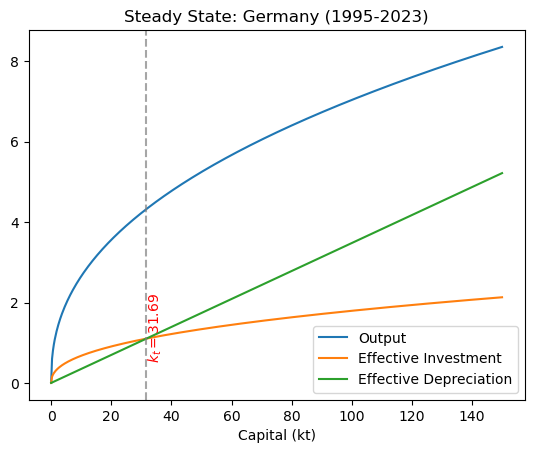

In [ ]:
# plt.plot(years, ngdp_np)
plt.plot(k, k**capital_share_np.mean(), label="Output")
plt.plot(k, investment, label="Effective Investment")
plt.plot(k, depreciation_line, label="Effective Depreciation")
plt.axvline(x=k_star, color='grey', linestyle="--", alpha=0.7)
plt.text(k_star, 0.5, f'$k_t = {k_star:.2f}$', color='red', rotation=90, verticalalignment='bottom')
plt.legend()
plt.xlabel(xlabel="Capital (kt)")
plt.title("Steady State: Germany (1995-2023)")


In [ ]:

def compute_k(k, alpha):
    eff_delta = effective_depreciation_rate
    s = savings_rate_np.mean()
    kt = k + s * k**alpha - eff_delta * k
    return kt

def years_to_stead_state(k, alpha, n):
    k_star = savings_rate_np.mean()
    count = 0
    kt = 10000
    k_values = [k]
    for i in range(n):
        kt = compute_k(k, alpha)
        count = count + 1
        k = kt
        k_values.append(k)
        if abs(k_star - k) < 0.001:
            break
    # print(f"Savings Rate (s): {s}\nEff. Depreciwation Rate (eff_delta): {eff_delta}\nalpha: {alpha}")
    print(f"Economy takes {count} years to achieve steady rate")
    return k_values

In [ ]:
k_star

31.687618422494666

In [ ]:
import numpy as np

def run_solow_simulation(k0, s, alpha, eff_delta, name="Simulation"):
    # 1. ALWAYS update k_star when alpha changes
    # Formula: (s / (n + g + delta))^(1 / (1 - alpha))
    k_star = (s / eff_delta)**(1 / (1 - alpha))
    
    kt = k0
    count = 0
    
    # 2. Run the loop until we are very close to the new k_star
    while abs(k_star - kt) > 0.0001:
        # solow model: kt+1 = kt + investment - depreciation
        kt = kt + s * (kt**alpha) - eff_delta * kt
        count += 1
        
        # Safety break to prevent infinite loops
        if count > 5000:
            break
            
    print(f"--- {name} ---")
    print(f"Target k*: {k_star:.4f}")
    print(f"Time to reach steady state: {count} years\n")
    return k_star, count

# parameters
s_mean = savings_rate_np.mean()
alpha_mean = capital_share_np.mean()
eff_delta_mean = effective_depreciation_rate.mean()

# computed alpha
k_star_1, years_1 = run_solow_simulation(5, s_mean, alpha_mean, eff_delta_mean, "Original Alpha")

# new alpha
alpha_high = alpha_mean + 0.1
k_star_2, years_2 = run_solow_simulation(5, s_mean, alpha_high, eff_delta_mean, "Higher Alpha")

--- Original Alpha ---
Target k*: 31.6876
Time to reach steady state: 633 years

--- Higher Alpha ---
Target k*: 65.4701
Time to reach steady state: 826 years

